In [31]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 


In [32]:
import string 
import re 
import nltk.corpus 
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [33]:
data = pd.read_csv('/kaggle/input/twitter-entity-sentiment-analysis/twitter_training.csv')
data.head()

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [34]:
data.columns

Index(['2401', 'Borderlands', 'Positive',
       'im getting on borderlands and i will murder you all ,'],
      dtype='object')

In [35]:
data.isnull().sum()

2401                                                       0
Borderlands                                                0
Positive                                                   0
im getting on borderlands and i will murder you all ,    686
dtype: int64

In [36]:
#check null
check_null = data[data.isnull().any(axis = 1)]
check_null

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
60,2411,Borderlands,Neutral,NaN
552,2496,Borderlands,Neutral,NaN
588,2503,Borderlands,Neutral,NaN
744,2532,Borderlands,Positive,NaN
1104,2595,Borderlands,Positive,NaN
...,...,...,...,...
73971,9073,Nvidia,Positive,NaN
73972,9073,Nvidia,Positive,NaN
74420,9154,Nvidia,Positive,NaN
74421,9154,Nvidia,Positive,NaN


In [37]:
data.dropna(subset = ['Positive','im getting on borderlands and i will murder you all ,'],inplace = True)

In [38]:
data.describe(include = "all")

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
count,73995.000000,73995,73995,73995
unique,NaN,32,4,69490
top,NaN,LeagueOfLegends,Negative,
freq,NaN,2377,22358,172
mean,6430.333685,NaN,NaN,NaN
std,3737.655932,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN
25%,3194.000000,NaN,NaN,NaN
50%,6418.000000,NaN,NaN,NaN
75%,9595.000000,NaN,NaN,NaN


In [39]:
print(data['Positive'].value_counts(normalize = True)*100)

Positive
Negative      30.215555
Positive      27.912697
Neutral       24.471924
Irrelevant    17.399824
Name: proportion, dtype: float64


In [40]:
print(data['Positive'].value_counts())

Positive
Negative      22358
Positive      20654
Neutral       18108
Irrelevant    12875
Name: count, dtype: int64


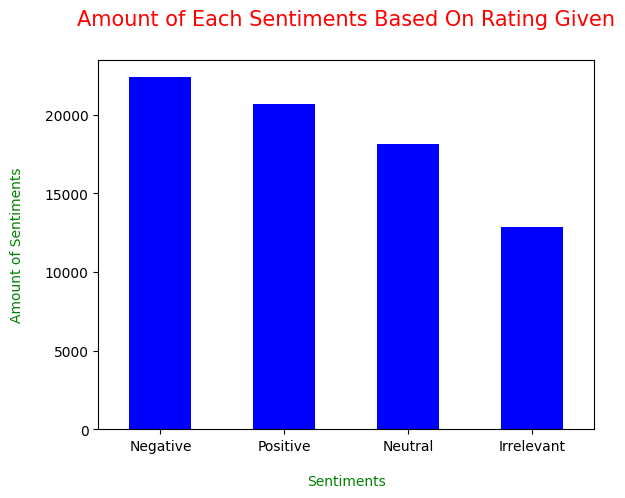

In [41]:
data["Positive"].value_counts().plot(kind = "bar", color = "blue")
plt.title("Amount of Each Sentiments Based On Rating Given", loc = "center", fontsize = 15, color = "red", pad = 25)
plt.xlabel("Sentiments", color = "green", fontsize = 10, labelpad = 15)
plt.xticks(rotation = 0)
plt.ylabel("Amount of Sentiments", color = "green", fontsize = 10, labelpad = 15)
plt.show()

In [49]:
#Text cleaning
def text_cleaning(text):
    emoji_pattern = re.compile(
        "["
        "\U0001f600-\U0001f64f"  
        "\U0001f300-\U0001f5ff" 
        "\U0001f680-\U0001f6ff"  
        "\U0001f1e0-\U0001f1ff"  
        "\U00002702-\U000027b0" # Thêm 0
        "\U000024c2-\U0001f251" # Thêm 0
        "]+", flags=re.UNICODE
    )
    text = text.lower()
    punc = str.maketrans(string.punctuation, ' '*len(string.punctuation))
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'\n',' ',text)
    text = emoji_pattern.sub(r' ',text)
    return text.strip()

In [50]:
print(text_cleaning('https:tungtomDepzai@gmail.com'))

https:tungtomdepzai@gmail.com


In [61]:
Stopwords = set(nltk.corpus.stopwords.words("english")) - set(["not"])
def text_processing(text):
    processed_text = []
    lemma = WordNetLemmatizer()
    tokens = nltk.word_tokenize(text)

    for word in tokens:
        if word not in Stopwords:
            processed_text.append(lemma.lemmatize(word))
    return (' '.join(processed_text))
    

In [62]:
print(text_processing('Hello I am Tung'))

Hello I Tung


In [63]:
data['im getting on borderlands and i will murder you all ,'] = data['im getting on borderlands and i will murder you all ,'].apply(lambda x:text_cleaning(x))
data['im getting on borderlands and i will murder you all ,'] = data['im getting on borderlands and i will murder you all ,'].apply(lambda x:text_processing(x))


In [66]:
data.head(n = 20)

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,"coming border kill ,"
1,2401,Borderlands,Positive,"im getting borderland kill ,"
2,2401,Borderlands,Positive,"im coming borderland murder ,"
3,2401,Borderlands,Positive,"im getting borderland 2 murder ,"
4,2401,Borderlands,Positive,"im getting borderland murder ,"
5,2402,Borderlands,Positive,spent hour making something fun . . . n't know...
6,2402,Borderlands,Positive,spent couple hour something fun ... n't know '...
7,2402,Borderlands,Positive,spent hour something fun ... n't know 'm huge ...
8,2402,Borderlands,Positive,spent hour making something fun . . . n't know...
9,2402,Borderlands,Positive,2010 spent hour making something fun . . . n't...


In [68]:
columns = ['2401','Borderlands']
data.drop(columns = columns,axis = 1, inplace = True)

In [69]:
data.head()

,Positive,"im getting on borderlands and i will murder you all ,"
0,Positive,"coming border kill ,"
1,Positive,"im getting borderland kill ,"
2,Positive,"im coming borderland murder ,"
3,Positive,"im getting borderland 2 murder ,"
4,Positive,"im getting borderland murder ,"


In [83]:
#feature engineering library
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import SMOTE #for imbalance data
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

In [94]:
#for model
from sklearn.naive_bayes import MultinomialNB,GaussianNB
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [85]:
encoder = LabelEncoder()
data['Positive'] = encoder.fit_transform(data['Positive'])
data['Positive'].value_counts()


Positive
1    22358
3    20654
2    18108
0    12875
Name: count, dtype: int64

In [86]:
tf_idf = TfidfVectorizer(max_features = 5000, ngram_range = (1, 2))
X = tf_idf.fit_transform(data['im getting on borderlands and i will murder you all ,'])
X.shape

(73995, 5000)

In [87]:
y = data['Positive']

In [88]:
Counter(y)

Counter({3: 20654, 2: 18108, 1: 22358, 0: 12875})

In [89]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)


In [96]:
model = MultinomialNB()
print(f'Bayes: {cross_val_score(model, X, y, cv = 10, scoring = "accuracy").mean()}')


Bayes: 0.41578221308211855


In [97]:
Param_NB = {
    'alpha': [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0],
    'fit_prior': [True, False]
}

# 2. Chạy GridSearch
grid_search_nb = GridSearchCV(
    estimator = MultinomialNB(), 
    param_grid = Param_NB, 
    scoring = "accuracy", 
    cv = 10, 
    n_jobs = -1
)

grid_search_nb.fit(X_train, y_train)

# 3. Xem kết quả
print("Best Accuracy NB: {:.2f} %".format(grid_search_nb.best_score_ * 100))
print("Best Parameters NB:", grid_search_nb.best_params_)

Best Accuracy NB: 64.44 %
Best Parameters NB: {'alpha': 0.001, 'fit_prior': True}


In [99]:
classifier = MultinomialNB(alpha=1.0)
classifier.fit(X_train, y_train)

prediction = classifier.predict(X_test)

In [100]:
accuracy_score(y_test,prediction)

0.6379485100344617

In [102]:

ConfusionMatrix = confusion_matrix(y_test, prediction)

In [103]:

# Plotting Function for Confusion Matrix
def plot_cm(cm, classes, title, normalized = False, cmap = plt.cm.Blues):

  plt.imshow(cm, interpolation = "nearest", cmap = cmap)
  plt.title(title, pad = 20)
  plt.colorbar()
  tick_marks = np.arange(len(classes))
  plt.xticks(tick_marks, classes)
  plt.yticks(tick_marks, classes)

  if normalized:
    cm = cm.astype('float') / cm.sum(axis = 1)[: np.newaxis]
    print("Normalized Confusion Matrix")
  else:
    print("Unnormalized Confusion Matrix")
  
  threshold = cm.max() / 2
  for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
      plt.text(j, i, cm[i, j], horizontalalignment = "center", color = "white" if cm[i, j] > threshold else "black")

  plt.tight_layout()
  plt.xlabel("Predicted Label", labelpad = 20)
  plt.ylabel("Real Label", labelpad = 20)

Unnormalized Confusion Matrix


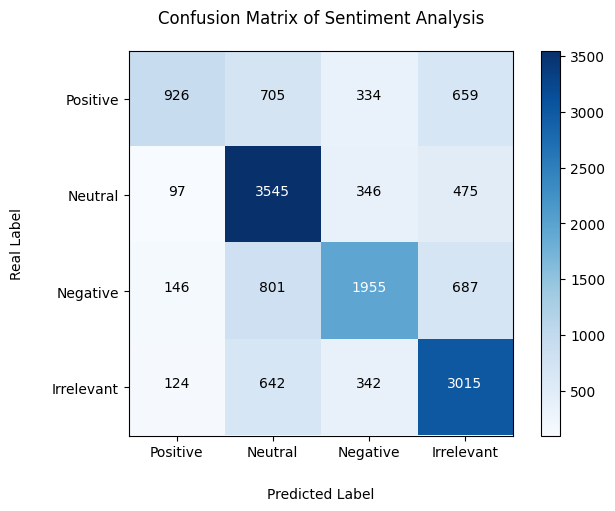

In [105]:

plot_cm(ConfusionMatrix, classes = ["Positive", "Neutral", "Negative","Irrelevant"], title = "Confusion Matrix of Sentiment Analysis")

In [106]:

print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

           0       0.72      0.35      0.47      2624
           1       0.62      0.79      0.70      4463
           2       0.66      0.54      0.60      3589
           3       0.62      0.73      0.67      4123

    accuracy                           0.64     14799
   macro avg       0.65      0.61      0.61     14799
weighted avg       0.65      0.64      0.63     14799

